In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S010_ex1.npz
/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S020_ex1.npz
/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S110_ex1.npz
/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S026_ex1.npz
/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S030_ex1.npz
/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S103_ex1.npz
/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S108_ex1.npz
/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S014_ex1.npz
/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S023_ex1.npz
/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S019_ex1.npz
/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S016_ex1.npz
/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S012_ex1.npz
/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1

In [2]:
# =========================
# CELDA 1: Imports + config
# =========================
import os
import re
import glob
import math
import json
import time
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

SEED = 123
random.seed(SEED)
np.random.seed(SEED)

# Rutas base (ajusta si cambia el dataset en Kaggle)
DB10_EMG = "/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG"
NINAPRO_EMG = "/kaggle/input/datasets/jorgeoc/ninapro-datasets-db1-db2-db3/NINAPRO_EXPORT_EMG"

OUT_ROOT = Path("/kaggle/working/prepared_myoware_v2")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Parámetros
FS = 2000
WIN_MS = 200
STRIDE_MS = 100

WIN = int(FS * WIN_MS / 1000)       # 400
STRIDE = int(FS * STRIDE_MS / 1000) # 200

SHARD_SIZE = 20000
MAX_FILES = None   # pon un entero si quieres debug rápido

print("OUT_ROOT:", OUT_ROOT)
print("WIN:", WIN, "STRIDE:", STRIDE)

OUT_ROOT: /kaggle/working/prepared_myoware_v2
WIN: 400 STRIDE: 200


In [3]:
# =========================
# CELDA 2: Helpers
# =========================
def safe_name(s: str) -> str:
    return re.sub(r"[\\/:*?\"<>|]+", "_", s).strip()

def robust_norm_1d(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-6
    z = (x - med) / (1.4826 * mad)
    return np.clip(z, -10, 10).astype(np.float32)

def to_1ch_myoware(emg):
    """
    Convierte EMG multicanal a un canal "modo MyoWare".
    Usa mediana por canal para robustez.
    """
    x = np.asarray(emg)

    if x.ndim == 1:
        return robust_norm_1d(x)

    if x.ndim != 2:
        raise ValueError(f"ndim inesperado: {x.ndim}")

    # Heurística: si viene como (C,T) y C <= 32, trasponer
    if x.shape[0] <= 32 and x.shape[0] < x.shape[1]:
        x = x.T

    # x debería quedar (T, C)
    if x.shape[1] > 1:
        x1 = np.median(x.astype(np.float32), axis=1)
    else:
        x1 = x[:, 0].astype(np.float32)

    return robust_norm_1d(x1)

def pick_label(d):
    if "restimulus" in d:
        return np.asarray(d["restimulus"]).squeeze()
    if "stimulus" in d:
        return np.asarray(d["stimulus"]).squeeze()
    return None

def windowize_signal_and_label(x, y=None, win=400, stride=200):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    T = len(x)
    if T < win:
        return None, None

    idxs = np.arange(0, T - win + 1, stride)
    X = np.stack([x[i:i+win] for i in idxs], axis=0).astype(np.float32)

    if y is None:
        return X, None

    y = np.asarray(y).reshape(-1)
    if len(y) != T:
        return X, None

    Y = np.zeros((len(idxs),), dtype=np.int32)
    for j, i in enumerate(idxs):
        seg = y[i:i+win]
        vals, cnts = np.unique(seg, return_counts=True)
        Y[j] = int(vals[np.argmax(cnts)])
    return X, Y

def compute_quality_score(x_clean, x_corr):
    """
    Score 0..1. 1 = muy sana, 0 = muy dañada
    Basado en SNR relativo aproximado.
    """
    x_clean = np.asarray(x_clean, dtype=np.float32)
    x_corr  = np.asarray(x_corr, dtype=np.float32)

    noise = x_corr - x_clean
    p_sig = float(np.mean(x_clean**2) + 1e-8)
    p_noi = float(np.mean(noise**2) + 1e-8)
    snr_db = 10.0 * math.log10(p_sig / p_noi)

    # mapear aproximadamente [-5, 25] dB -> [0,1]
    q = (snr_db + 5.0) / 30.0
    q = float(np.clip(q, 0.0, 1.0))
    return q, snr_db

def corrupt_window(xw, rng):
    """
    Devuelve:
      x_corr: señal corrupta
      meta: dict con tipos de corrupción aplicados
    """
    x = xw.astype(np.float32).copy()
    applied = []

    # ruido gaussiano
    if rng.random() < 0.65:
        sigma = rng.uniform(0.05, 0.35)
        x += rng.normal(0, sigma, size=x.shape).astype(np.float32)
        applied.append(f"gaussian_sigma={sigma:.3f}")

    # drift
    if rng.random() < 0.45:
        amp = rng.uniform(0.2, 1.2)
        freq = rng.uniform(0.2, 1.5)
        t = np.linspace(0, 1, len(x), dtype=np.float32)
        x += (amp * np.sin(2*np.pi*freq*t)).astype(np.float32)
        applied.append(f"drift_amp={amp:.3f}_freq={freq:.3f}")

    # dropout
    if rng.random() < 0.25:
        n = int(rng.integers(10, 80))
        start = int(rng.integers(0, len(x)-n))
        x[start:start+n] = 0.0
        applied.append(f"dropout_len={n}")

    # clipping
    if rng.random() < 0.25:
        clipv = rng.uniform(2.0, 6.0)
        x = np.clip(x, -clipv, clipv)
        applied.append(f"clip={clipv:.3f}")

    # impulsos
    if rng.random() < 0.20:
        k = int(rng.integers(1, 5))
        for _ in range(k):
            pos = int(rng.integers(0, len(x)))
            x[pos] += float(rng.uniform(-8, 8))
        applied.append(f"impulses={k}")

    if not applied:
        applied.append("clean_like")

    return x.astype(np.float32), {"corruptions": applied}

def write_npy(folder, name, arr):
    folder = OUT_ROOT / folder
    folder.mkdir(parents=True, exist_ok=True)
    np.save(folder / name, arr)

def shard_save(folder, prefix, arrays, shard_idx):
    folder = OUT_ROOT / folder
    folder.mkdir(parents=True, exist_ok=True)
    for k, v in arrays.items():
        np.save(folder / f"{k}_{shard_idx:04d}.npy", v)

In [4]:
# =========================
# CELDA 3: Localizar .npz
# =========================
npz_files = sorted(glob.glob(os.path.join(DB10_EMG, "**", "*.npz"), recursive=True))
npz_files += sorted(glob.glob(os.path.join(NINAPRO_EMG, "**", "*.npz"), recursive=True))

if MAX_FILES is not None:
    npz_files = npz_files[:MAX_FILES]

print("Total .npz encontrados:", len(npz_files))
print("Ejemplo:", npz_files[:3])

Total .npz encontrados: 410
Ejemplo: ['/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S010_ex1.npz', '/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S011_ex1.npz', '/kaggle/input/datasets/jorgeoc/ninapro-db10/DB10_EXPORT_EMG/MDS1/S012_ex1.npz']


In [5]:
# =========================
# CELDA 4: Construcción de datasets
# =========================
rng = np.random.default_rng(SEED)

intent_X_buf, intent_Y_buf = [], []
quality_X_buf, quality_Qscore_buf, quality_Qlabel_buf = [], [], []
rest_Xcorr_buf, rest_Xclean_buf, rest_Qscore_buf = [], [], []
quality_meta = []

intent_shard = 0
quality_shard = 0
rest_shard = 0

total_windows = 0
total_intent1 = 0

for fi, fp in enumerate(npz_files, start=1):
    try:
        d = np.load(fp, allow_pickle=True)

        # buscar EMG
        emg_key = None
        for k in d.files:
            kl = k.lower()
            if "emg" in kl:
                emg_key = k
                break

        if emg_key is None:
            continue

        emg = d[emg_key]
        label = pick_label(d)

        x1 = to_1ch_myoware(emg)
        Xw, Yw = windowize_signal_and_label(x1, label, WIN, STRIDE)

        if Xw is None:
            continue

        # si no hay labels sample-wise, no sirve para intent binario
        if Yw is None:
            continue

        Y_intent = (Yw != 0).astype(np.int32)

        total_windows += len(Xw)
        total_intent1 += int(Y_intent.sum())

        for j in range(len(Xw)):
            x_clean = Xw[j]
            y_bin = Y_intent[j]

            # intent dataset
            intent_X_buf.append(x_clean[None, :])  # (1, T)
            intent_Y_buf.append(np.array([y_bin], dtype=np.float32))

            # corruption + quality
            x_corr, meta = corrupt_window(x_clean, rng)
            q_score, snr_db = compute_quality_score(x_clean, x_corr)
            q_label = 1 if q_score >= 0.60 else 0  # 1 = sana/aceptable, 0 = mala

            quality_X_buf.append(x_corr[None, :])
            quality_Qscore_buf.append(np.array([q_score], dtype=np.float32))
            quality_Qlabel_buf.append(np.array([q_label], dtype=np.float32))
            quality_meta.append({
                "file": fp,
                "idx": j,
                "intent": int(y_bin),
                "q_score": float(q_score),
                "q_label": int(q_label),
                "snr_db": float(snr_db),
                "corruptions": meta["corruptions"],
            })

            # restoration dataset SOLO si hay intención
            if y_bin == 1:
                rest_Xcorr_buf.append(x_corr[None, :])
                rest_Xclean_buf.append(x_clean[None, :])
                rest_Qscore_buf.append(np.array([q_score], dtype=np.float32))

            # shard save intent
            if len(intent_X_buf) >= SHARD_SIZE:
                shard_save("intent_dataset", "intent", {
                    "X": np.stack(intent_X_buf).astype(np.float32),
                    "Y": np.concatenate(intent_Y_buf).astype(np.float32),
                }, intent_shard)
                intent_X_buf, intent_Y_buf = [], []
                intent_shard += 1

            # shard save quality
            if len(quality_X_buf) >= SHARD_SIZE:
                shard_save("quality_dataset", "quality", {
                    "X": np.stack(quality_X_buf).astype(np.float32),
                    "Qscore": np.concatenate(quality_Qscore_buf).astype(np.float32),
                    "Qlabel": np.concatenate(quality_Qlabel_buf).astype(np.float32),
                }, quality_shard)
                with open(OUT_ROOT / "quality_dataset" / f"meta_{quality_shard:04d}.json", "w") as f:
                    json.dump(quality_meta, f)
                quality_X_buf, quality_Qscore_buf, quality_Qlabel_buf, quality_meta = [], [], [], []
                quality_shard += 1

            # shard save restoration
            if len(rest_Xcorr_buf) >= SHARD_SIZE:
                shard_save("restoration_dataset", "rest", {
                    "Xcorr": np.stack(rest_Xcorr_buf).astype(np.float32),
                    "Xclean": np.stack(rest_Xclean_buf).astype(np.float32),
                    "Qscore": np.concatenate(rest_Qscore_buf).astype(np.float32),
                }, rest_shard)
                rest_Xcorr_buf, rest_Xclean_buf, rest_Qscore_buf = [], [], []
                rest_shard += 1

        if fi % 20 == 0:
            print(f"[{fi}/{len(npz_files)}] procesados... total_windows={total_windows}")

    except Exception as e:
        print("ERROR en", fp, "->", repr(e))

# flush final
if len(intent_X_buf):
    shard_save("intent_dataset", "intent", {
        "X": np.stack(intent_X_buf).astype(np.float32),
        "Y": np.concatenate(intent_Y_buf).astype(np.float32),
    }, intent_shard)

if len(quality_X_buf):
    shard_save("quality_dataset", "quality", {
        "X": np.stack(quality_X_buf).astype(np.float32),
        "Qscore": np.concatenate(quality_Qscore_buf).astype(np.float32),
        "Qlabel": np.concatenate(quality_Qlabel_buf).astype(np.float32),
    }, quality_shard)
    with open(OUT_ROOT / "quality_dataset" / f"meta_{quality_shard:04d}.json", "w") as f:
        json.dump(quality_meta, f)

if len(rest_Xcorr_buf):
    shard_save("restoration_dataset", "rest", {
        "Xcorr": np.stack(rest_Xcorr_buf).astype(np.float32),
        "Xclean": np.stack(rest_Xclean_buf).astype(np.float32),
        "Qscore": np.concatenate(rest_Qscore_buf).astype(np.float32),
    }, rest_shard)

print("Listo.")
print("Total windows:", total_windows)
print("Total intent=1:", total_intent1)
print("Frac intent=1:", total_intent1 / max(total_windows, 1))

[200/410] procesados... total_windows=1215
[220/410] procesados... total_windows=16690
[240/410] procesados... total_windows=32603
[260/410] procesados... total_windows=47833
[280/410] procesados... total_windows=71668
[300/410] procesados... total_windows=223607
[320/410] procesados... total_windows=380350
[340/410] procesados... total_windows=535900
[360/410] procesados... total_windows=707329
[380/410] procesados... total_windows=878820
[400/410] procesados... total_windows=1031053
Listo.
Total windows: 1120413
Total intent=1: 620364
Frac intent=1: 0.5536922545525623


intent shards: 57
quality shards: 57
restoration shards: 32
Intent X: (20000, 1, 400) float32
Intent Y: (20000,) float32 pos frac: 0.40845
Quality X: (20000, 1, 400) float32
Qscore: (20000,) float32 min/max: 0.0 1.0
Qlabel balance: Counter({1: 10528, 0: 9472})


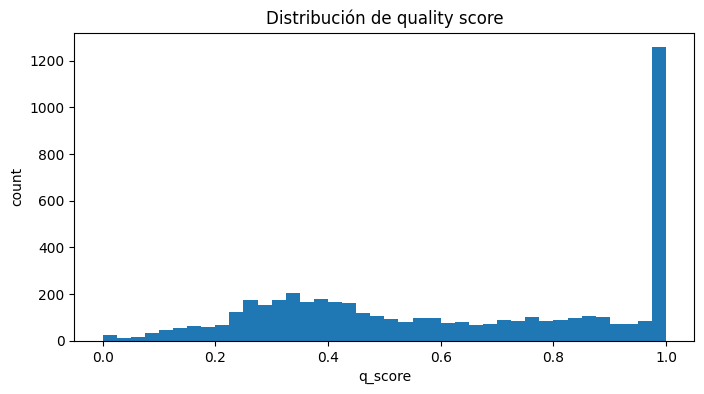

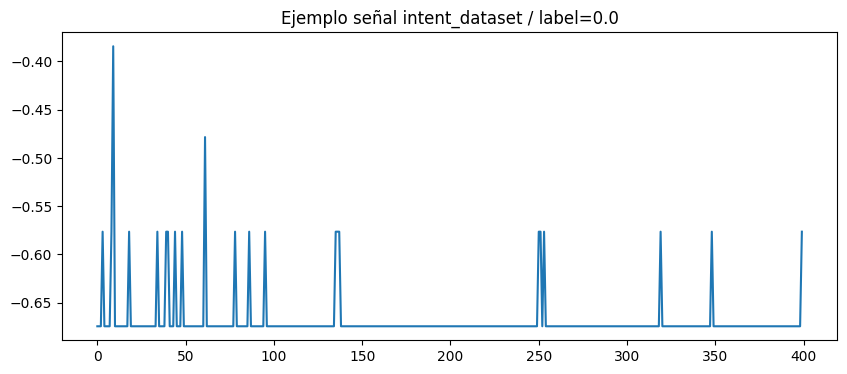

In [6]:
# =========================
# CELDA 5: Inspección rápida
# =========================
import glob, os, json
from collections import Counter

intent_files = sorted(glob.glob(str(OUT_ROOT / "intent_dataset" / "X_*.npy")))
quality_files = sorted(glob.glob(str(OUT_ROOT / "quality_dataset" / "X_*.npy")))
rest_xcorr_files = sorted(glob.glob(str(OUT_ROOT / "restoration_dataset" / "Xcorr_*.npy")))

print("intent shards:", len(intent_files))
print("quality shards:", len(quality_files))
print("restoration shards:", len(rest_xcorr_files))

# cargar una muestra
Xi = np.load(intent_files[0], mmap_mode="r")
Yi = np.load(str(OUT_ROOT / "intent_dataset" / "Y_0000.npy"), mmap_mode="r")

Xq = np.load(quality_files[0], mmap_mode="r")
Qscore = np.load(str(OUT_ROOT / "quality_dataset" / "Qscore_0000.npy"), mmap_mode="r")
Qlabel = np.load(str(OUT_ROOT / "quality_dataset" / "Qlabel_0000.npy"), mmap_mode="r")

print("Intent X:", Xi.shape, Xi.dtype)
print("Intent Y:", Yi.shape, Yi.dtype, "pos frac:", Yi.mean())

print("Quality X:", Xq.shape, Xq.dtype)
print("Qscore:", Qscore.shape, Qscore.dtype, "min/max:", Qscore.min(), Qscore.max())
print("Qlabel balance:", Counter(Qlabel.astype(int).tolist()))

plt.figure(figsize=(8,4))
plt.hist(Qscore[:5000], bins=40)
plt.title("Distribución de quality score")
plt.xlabel("q_score")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(Xi[0,0])
plt.title(f"Ejemplo señal intent_dataset / label={Yi[0]}")
plt.show()